In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("synthetic_dataset_10000x20.csv")

## EDA(Exploratory Data Analysis):

- Check dataset shape, data types, missing values, and unique values.
- Plot distributions of numeric features (histograms, boxplots).
- Analyze categorical variables (bar charts, value counts).
- Detect outliers and discuss strategies to handle them.
- Explore correlations (heatmap, pairplot).

In [4]:
df.shape

(10000, 21)

In [5]:
df.sample(5)

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
1957,CUST009700,60,98695.0,2272.0,1573.0,1,685.504937,8514.0,24,11.6,...,Bachelors,Single,East,0,1,2019-01-11,4,0.086,-0.279415,1
7443,CUST005592,27,53065.0,1589.0,1674.0,3,646.636371,1000.0,48,6.7,...,Bachelors,Married,South,0,1,2020-02-24,0,0.019,0.427380,1
3590,CUST000757,45,27887.0,5471.0,1547.0,2,646.309112,23188.0,24,7.9,...,Bachelors,Married,West,0,1,2019-11-28,3,0.831,-0.977530,0
6937,CUST005669,20,27134.0,5355.0,3022.0,3,748.295474,20384.0,48,12.2,...,Bachelors,Single,West,0,0,2019-09-29,6,0.751,0.909297,0
2633,CUST007703,53,26866.0,3535.0,2937.0,1,620.310818,15828.0,48,4.5,...,Other,Widowed,East,0,1,2020-04-28,1,0.589,-0.832267,0


In [6]:
df.dtypes

customer_id             object
age                      int64
income                 float64
savings                float64
monthly_expenses       float64
num_dependents           int64
credit_score           float64
loan_amount            float64
loan_term_months         int64
employment_years       float64
home_ownership          object
education               object
marital_status          object
region                  object
recent_default           int64
has_credit_card          int64
signup_date             object
signup_dayofweek         int64
debt_to_income         float64
sin_age                float64
target_default_risk      int64
dtype: object

In [8]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100 # since the percentages of the null values in the given column is small~3% so we can impute them with mean or median. 

customer_id            0.00
age                    0.00
income                 3.18
savings                3.11
monthly_expenses       3.25
num_dependents         0.00
credit_score           3.26
loan_amount            0.00
loan_term_months       0.00
employment_years       0.00
home_ownership         0.00
education              0.00
marital_status         0.00
region                 0.00
recent_default         0.00
has_credit_card        0.00
signup_date            0.00
signup_dayofweek       0.00
debt_to_income         0.00
sin_age                0.00
target_default_risk    0.00
dtype: float64

In [13]:
df.nunique()

customer_id            10000
age                       57
income                  9108
savings                 6498
monthly_expenses        3068
num_dependents             8
credit_score            9647
loan_amount             7999
loan_term_months           6
employment_years         182
home_ownership             4
education                  6
marital_status             4
region                     4
recent_default             2
has_credit_card            2
signup_date             1982
signup_dayofweek           7
debt_to_income          1261
sin_age                   57
target_default_risk        2
dtype: int64

In [15]:
df.isnull().sum()

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.drop("customer_id",axis=1,inplace=True) # Unnecessary column as index is already givivng unique values to each rows.

#### Checking for Normality of the Distribution and Skewness of Numerical-Continuous Columns:

- Skewness must be in the range of +0.5 to -0.5 for the distribution to be normal.

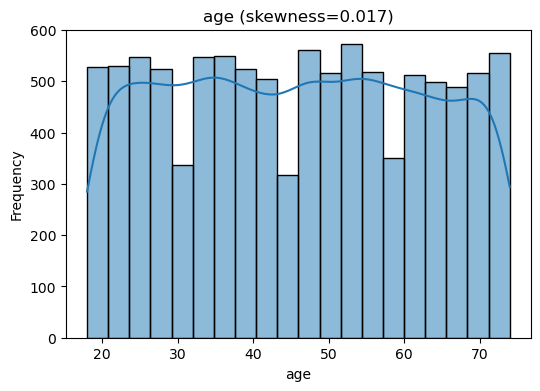

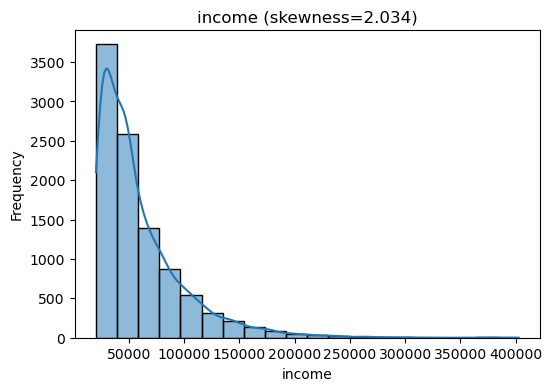

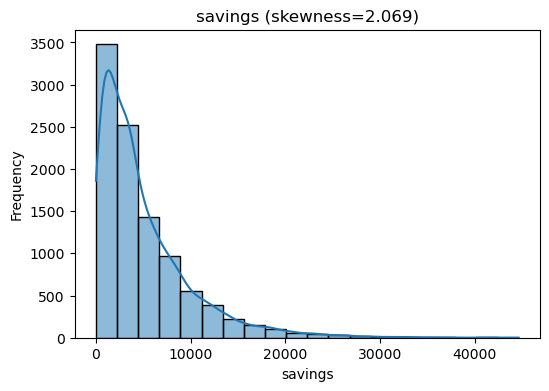

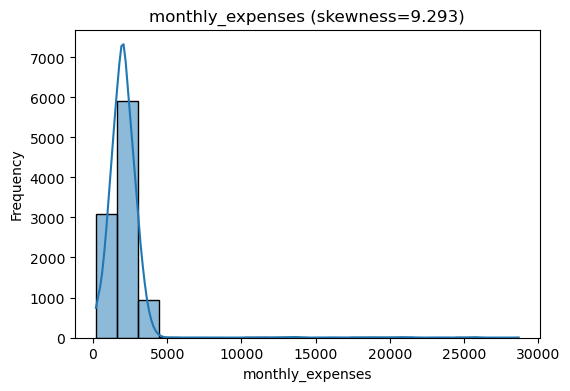

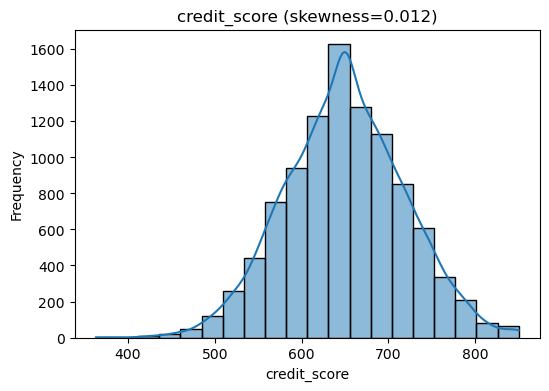

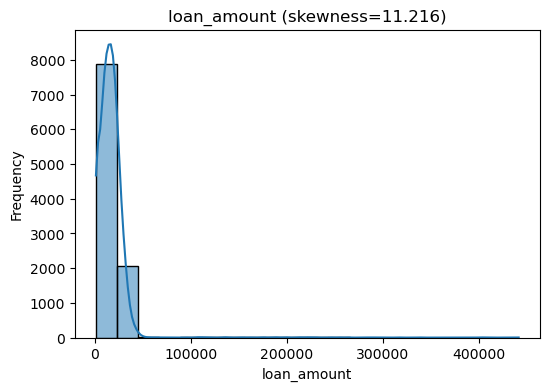

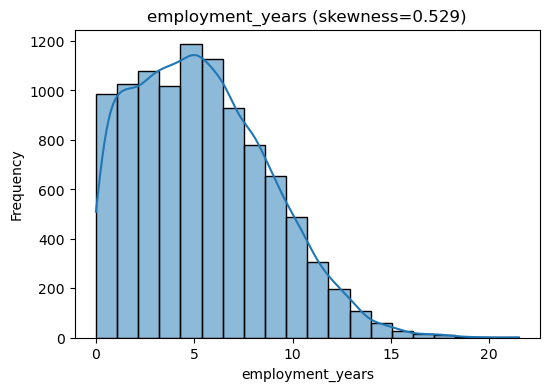

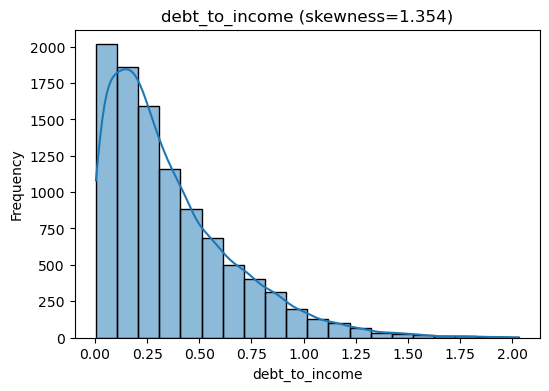

In [25]:
num_cont_vars=["age","income","savings","monthly_expenses","credit_score","loan_amount","employment_years","debt_to_income"]
for var in num_cont_vars:
    skew=df[var].skew()
    plt.figure(figsize=(6,4))
    sns.histplot(df[var],kde=True,bins=20)
    plt.title(f"{var} (skewness={skew:.3f})")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

Discussing Skewness:
- age=0.017, Normal distribution
- income=2.034, Non-Normal distribution
- savings=2.069, Non-Normal distribution
- monthly expenses=9.293, Non-Normal distribution
- credit score=0.012, Normal distribution
- loan amount=11.216, Non-Normal distribution
- employment years=0.529, Non- Normal distribution
- debt to income=1.354, Non-Normal distribution

#### Checking for an Outliers using Box Plot of Numerically-Continuous columns:

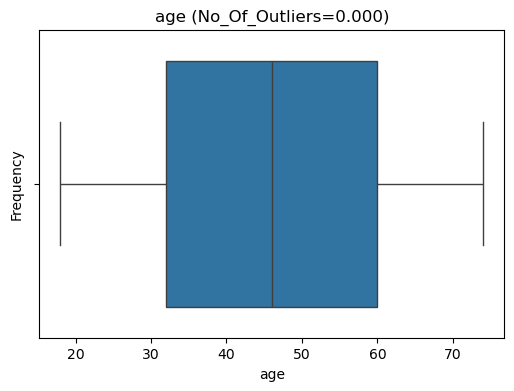

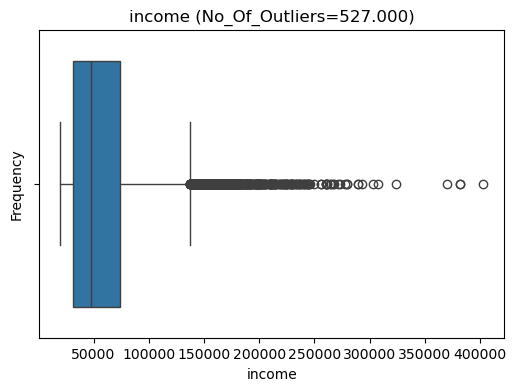

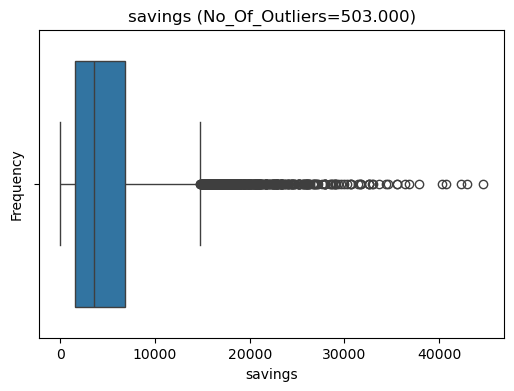

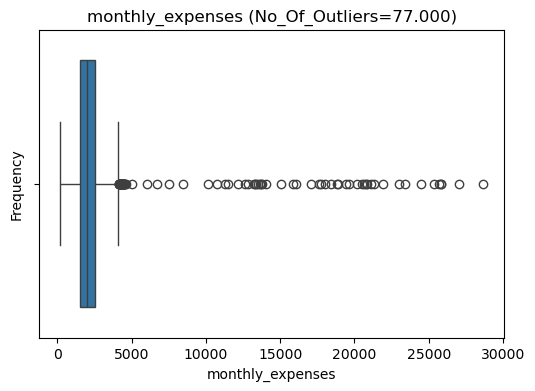

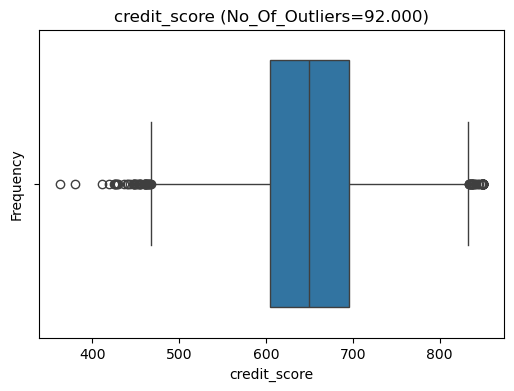

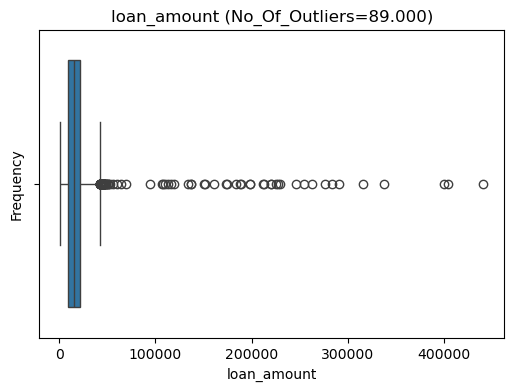

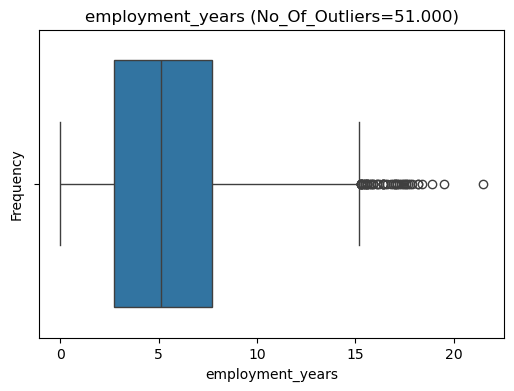

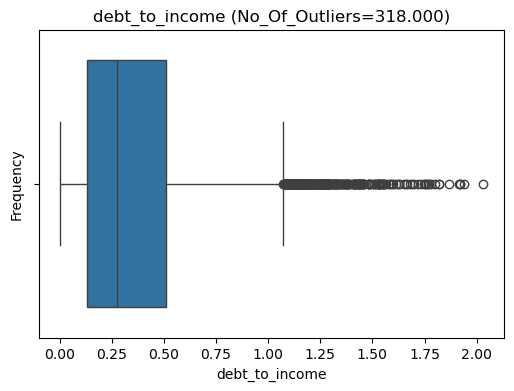

In [49]:
for var in num_cont_vars:
    Q1=df[var].quantile(0.25)
    Q3=df[var].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    Outliers=df[(df[var]<lower_bound)|(df[var]>upper_bound)]
    Num=len(Outliers)
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[var],data=df)
    plt.title(f"{var} (No_Of_Outliers={Num:.3f})")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

#### As we can see that the number of outliers in the various columns are:
- age=0 (0%)
- income=527(5.27%), They are those who have higher salaries
- savings=503(5.03%), They are those who have higher savings.
- monthly expenses=77(0.77%), They are those who have higher monthly expenses.
- credit score=92(0.92%), They are those who having higher as well as lower credit score.
- loan amount=89(0.89%), They are those who have higher loan amount.
- employment years=51(0.51%), They are those who have higher no. of employment years.
- debt to income=318(3.18%), They are those who have higher debt to income.


In [43]:
cat_numdisct_vars=["home_ownership","education","marital_status","region","signup_dayofweek","has_credit_card","recent_default","loan_term_months","num_dependents"]
for var in cat_numdisct_vars:
    print(f"\nFrequency table for {var}")
    print(df[var].value_counts())


Frequency table for home_ownership
home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64

Frequency table for education
education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64

Frequency table for marital_status
marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64

Frequency table for region
region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64

Frequency table for signup_dayofweek
signup_dayofweek
5    1488
2    1461
0    1454
4    1430
6    1420
3    1385
1    1362
Name: count, dtype: int64

Frequency table for has_credit_card
has_credit_card
1    6948
0    3052
Name: count, dtype: int64

Frequency table for recent_default
recent_default
0    9530
1     470
Name: count, dtype: int64

Frequency table for loan_term_months
loan_term_months
48    2998
36   

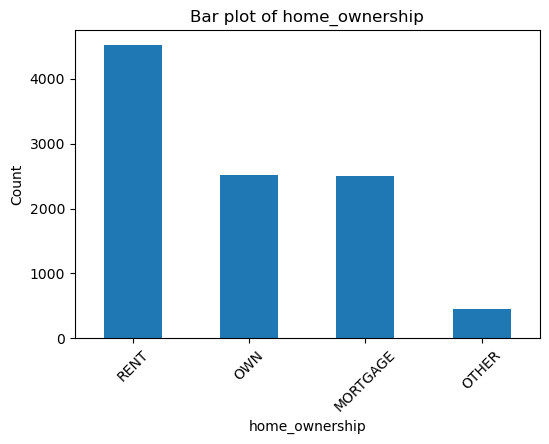

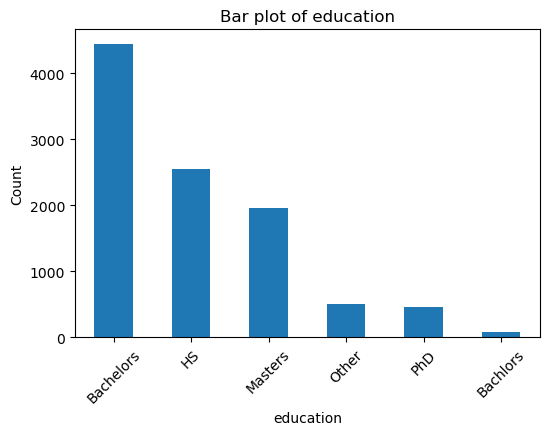

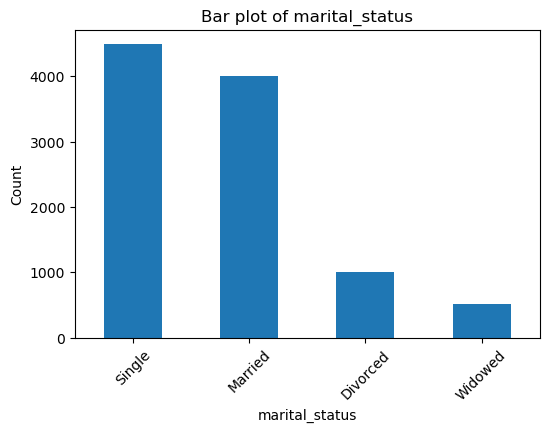

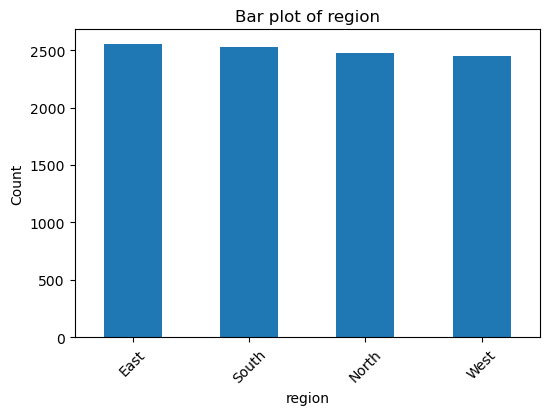

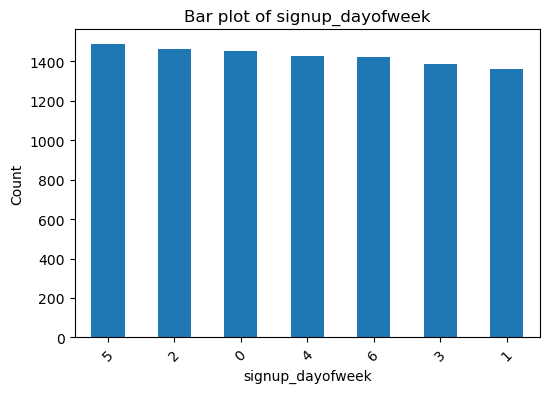

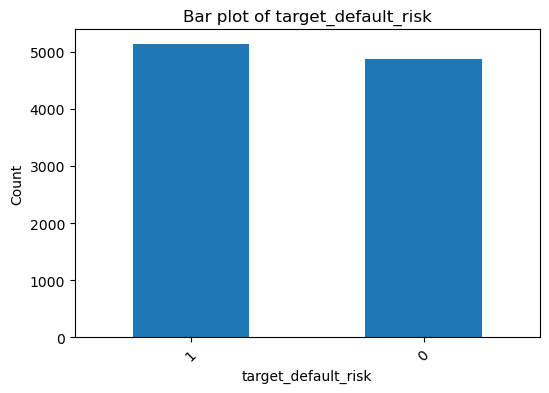

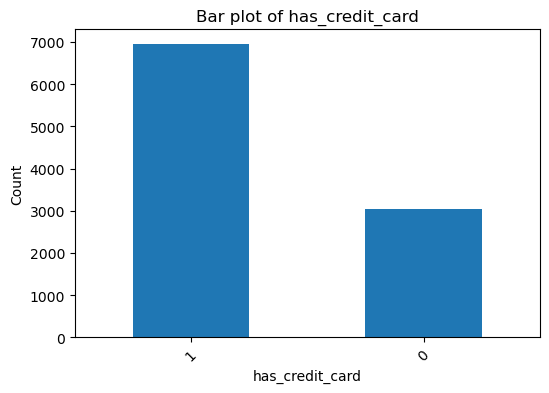

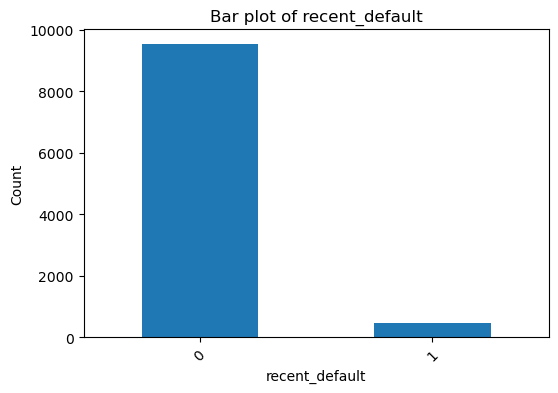

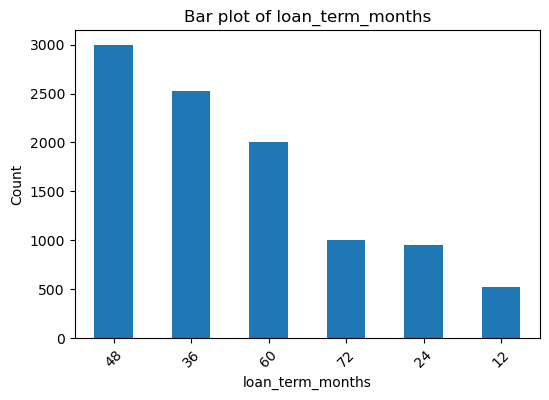

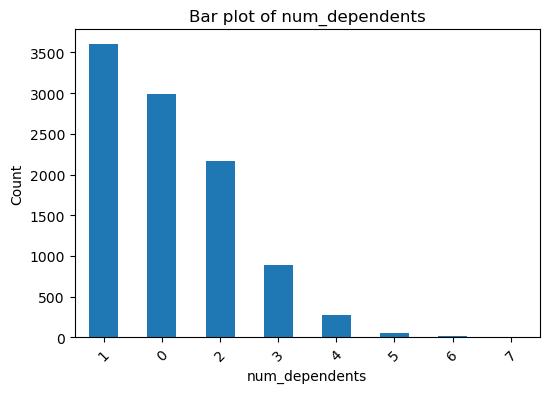

In [27]:
for var in cat_numdisct_vars:
    plt.figure(figsize=(6,4))
    df[var].value_counts().plot(kind="bar")
    plt.title(f"Bar plot of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

<Axes: xlabel='income', ylabel='loan_amount'>

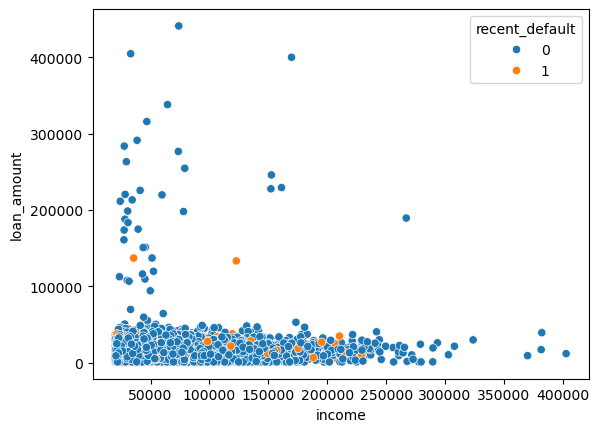

In [32]:
sns.scatterplot(x="income",y="loan_amount",data=df,hue="recent_default") 

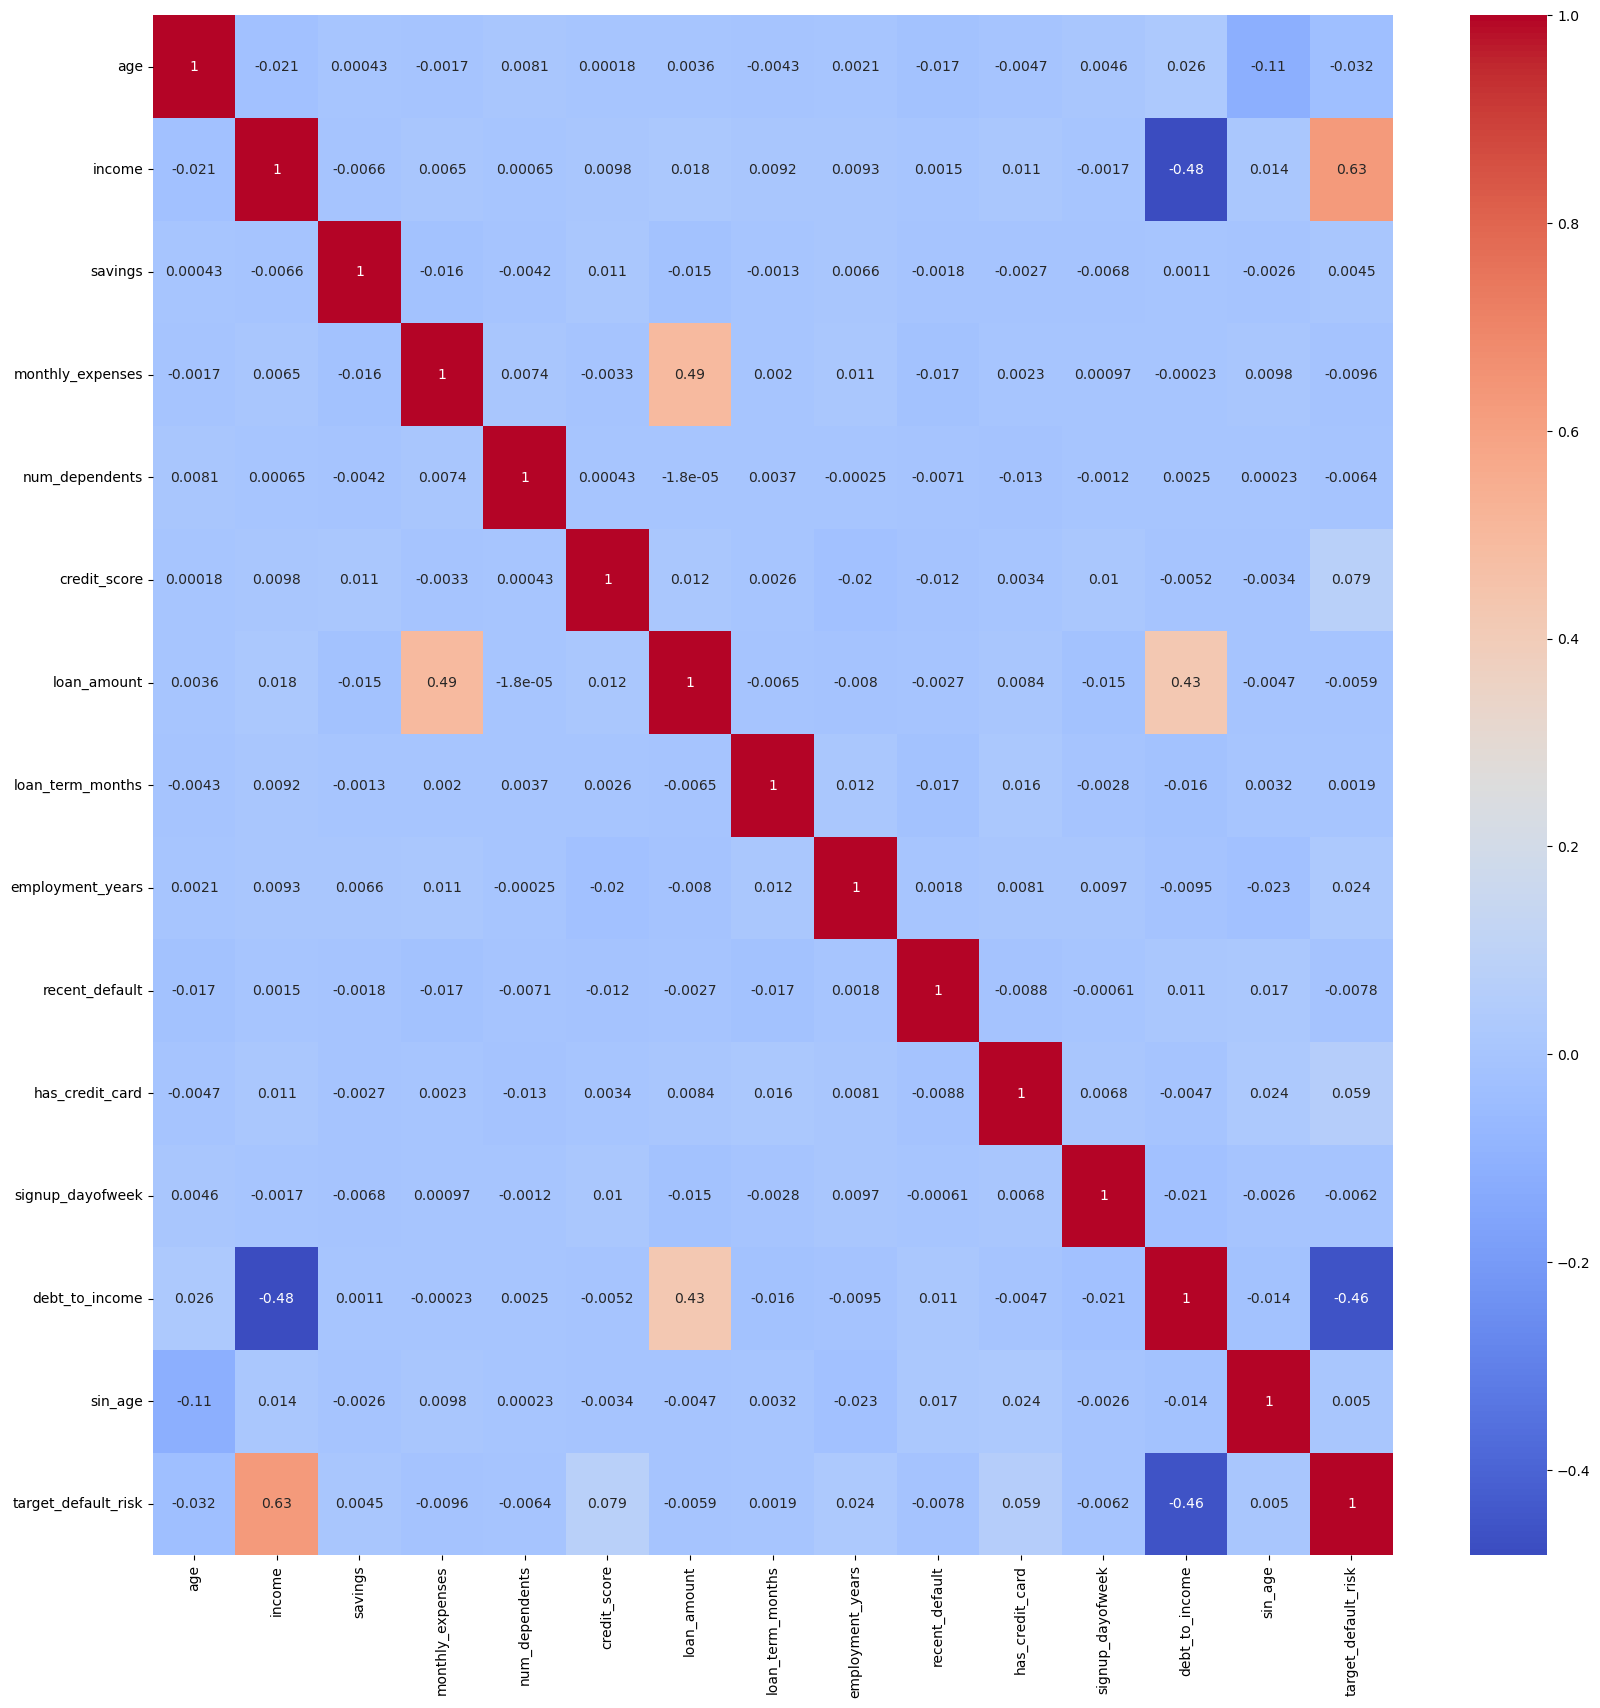

In [39]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

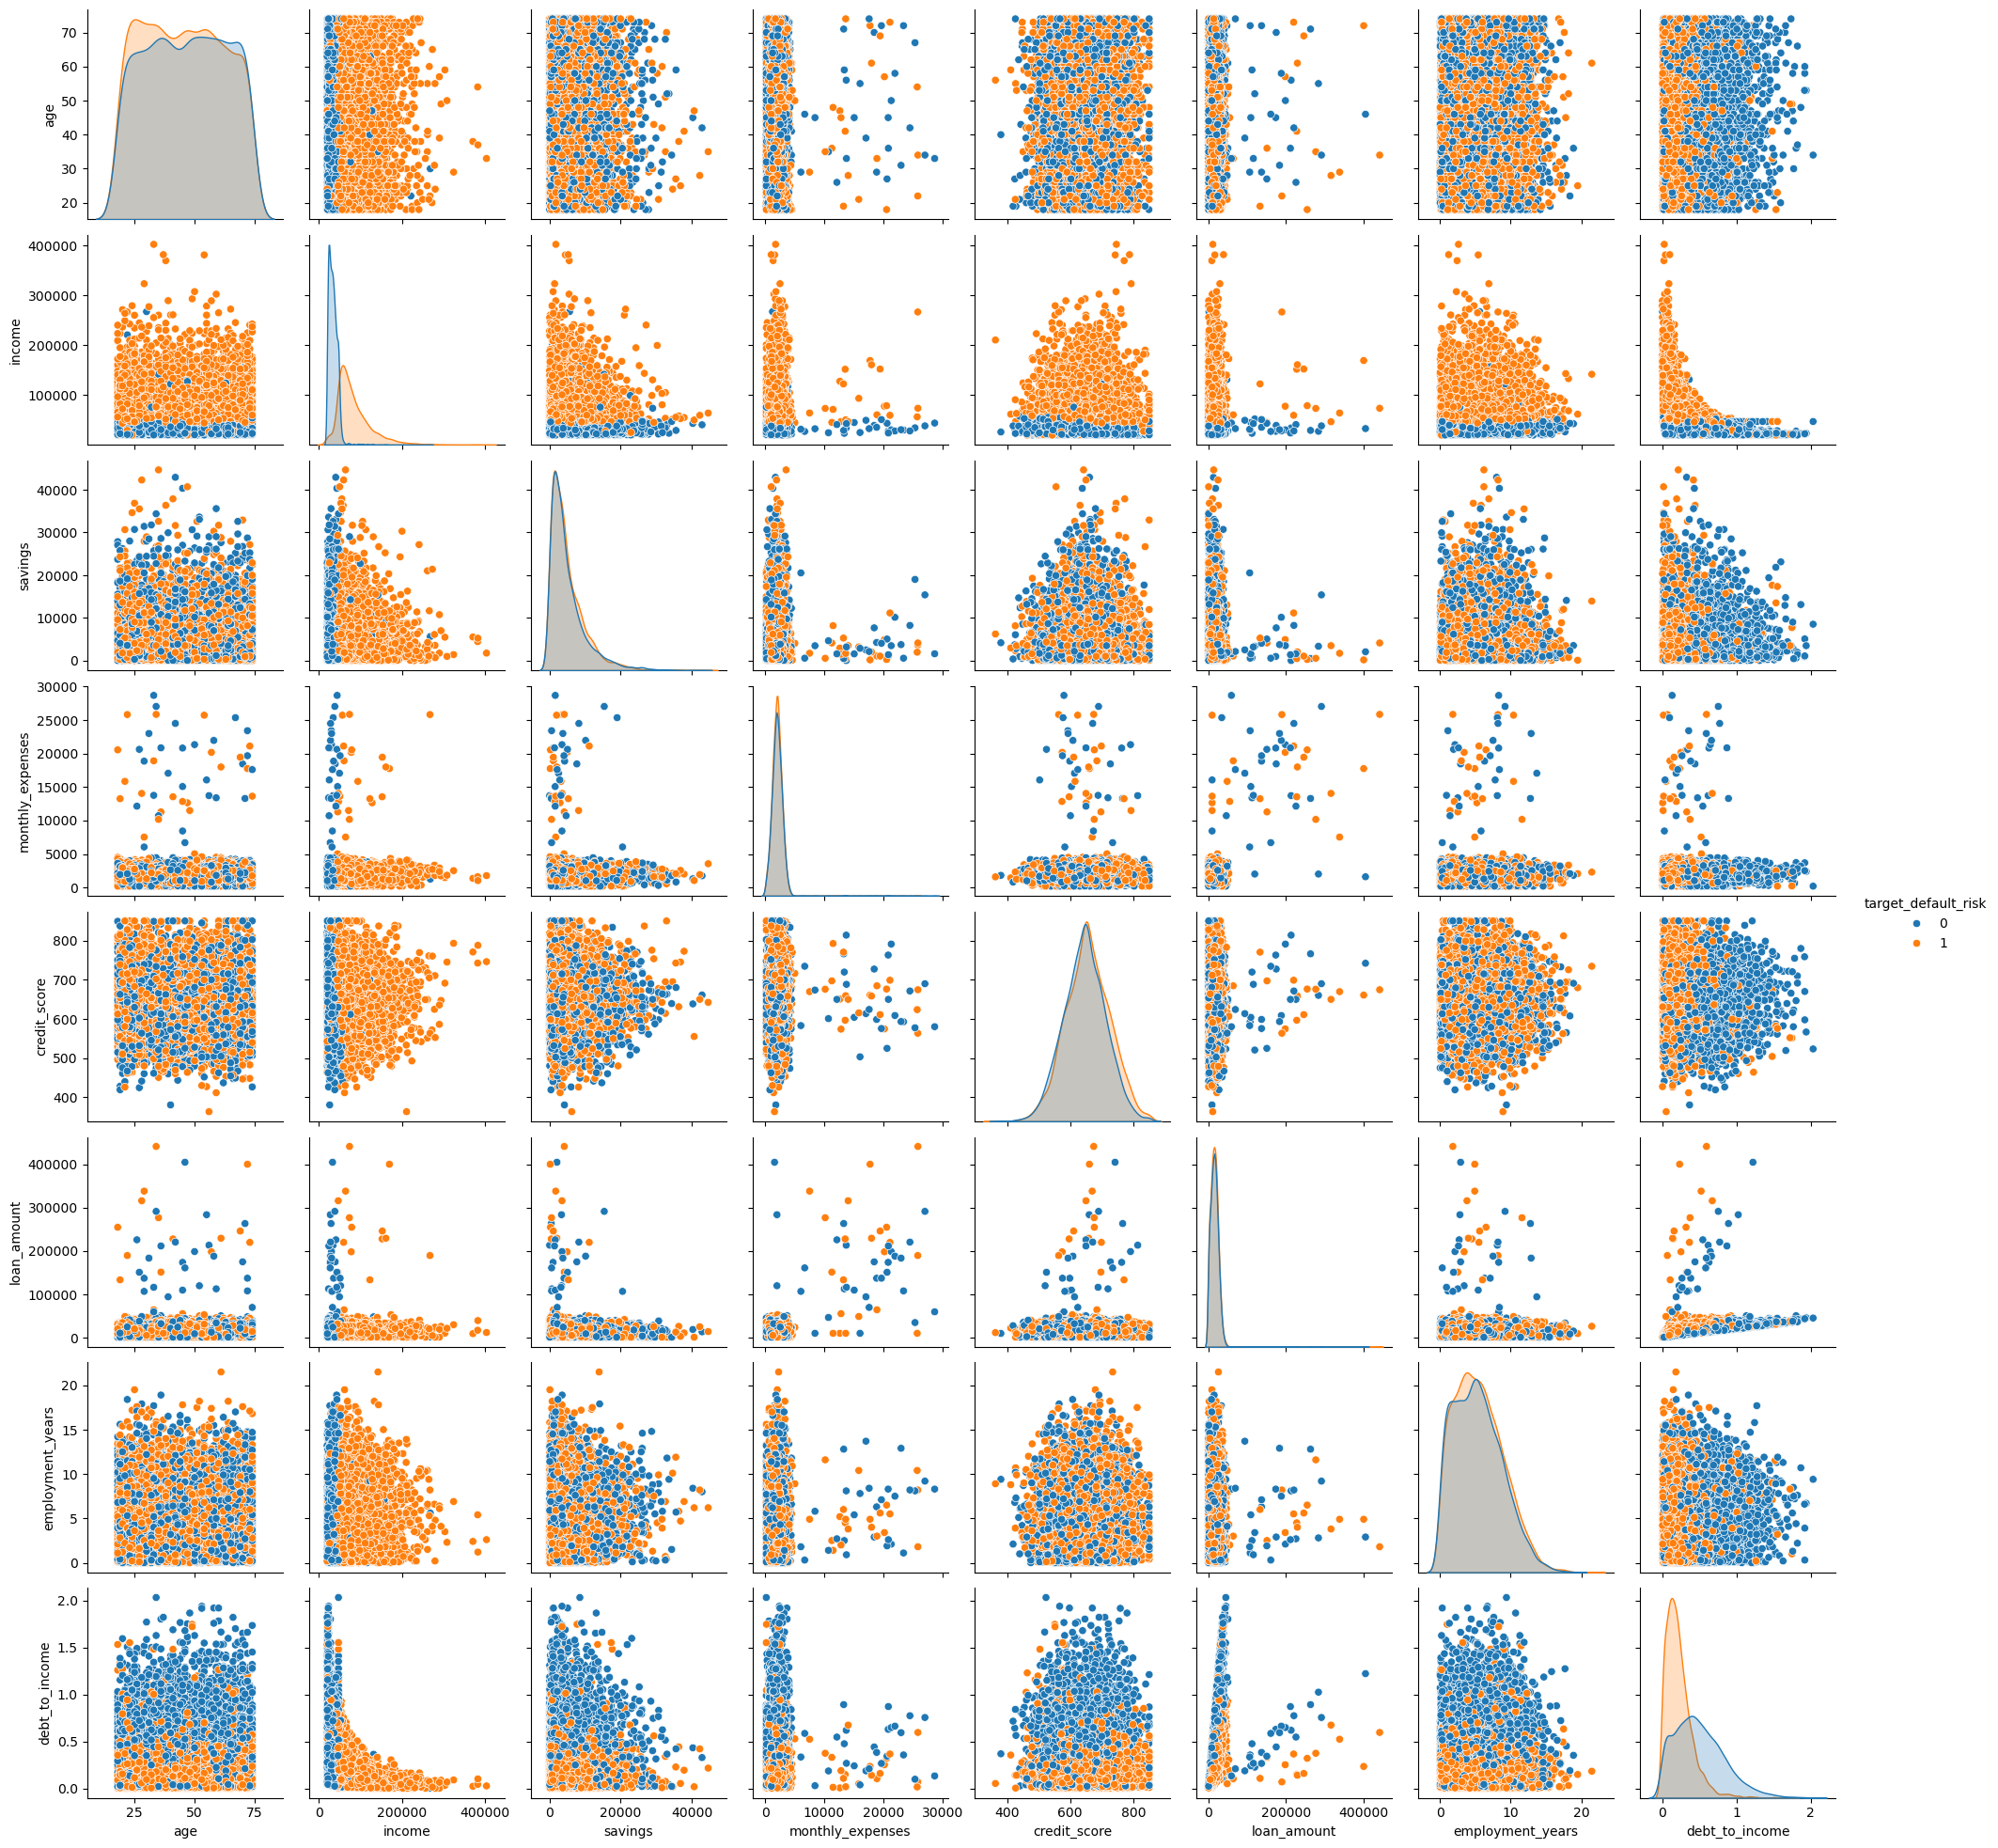

In [41]:
sns.pairplot(data=df,vars=num_cont_vars,hue="target_default_risk")

## Class balance in target_default_risk

- Look at class balance in `target_default_risk` column.


In [44]:
df["target_default_risk"].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

In [47]:
df["target_default_risk"].value_counts(normalize=True)*100
# This shows that the target column is balanced as both the classes have almost equal weightage.

target_default_risk
1    51.32
0    48.68
Name: proportion, dtype: float64

## Data-Preprocessing Steps:

- Handling Missing values (imputation strategies, imputing with median as median is least affected by an outlier)

In [4]:
df["income"]=df["income"].fillna(df["income"].median())
df["savings"]=df["savings"].fillna(df["savings"].median())
df["monthly_expenses"]=df["monthly_expenses"].fillna(df["monthly_expenses"].median())
df["credit_score"]=df["credit_score"].fillna(df["credit_score"].median())

- Handling Categorical Columns 

In [60]:
cat_cols=df.select_dtypes(include="object").columns
print(cat_cols)

Index(['home_ownership', 'education', 'marital_status', 'region',
       'signup_date'],
      dtype='object')


In [61]:
cat_columns=['home_ownership','education','marital_status','region','signup_date']
for var in cat_columns:
    print(f"\nFrequency table for {var}")
    print(df[var].value_counts())


Frequency table for home_ownership
home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64

Frequency table for education
education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64

Frequency table for marital_status
marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64

Frequency table for region
region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64

Frequency table for signup_date
signup_date
2018-06-22    14
2021-04-14    13
2021-01-27    13
2021-11-14    13
2022-05-07    12
              ..
2023-04-16     1
2022-05-31     1
2020-03-22     1
2022-07-31     1
2018-11-04     1
Name: count, Length: 1982, dtype: int64


In [5]:
# Home Owner ship doesn't has natural numerical order so we use One-Hot Encoding on it:
df=pd.get_dummies(df,columns=["home_ownership"],dtype=int)

In [6]:
# Education has order as other<HS<Bachelors<Masters<PhD so it has order so ordinal encoding:
# Here Bachelors is wriiten in two different ways, due to which its distinctly counted so we fix it first.
df['education']=df['education'].replace({'Bachlors':'Bachelors'})

In [7]:
df['education'].value_counts()

education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64

In [8]:
# Applying ordinal encoding
education_dict={
    'HS':1,
    'Bachelors':2,
    'Masters':3,
    'PhD':4,
    'Other':0
}
df["education"]=df["education"].map(education_dict)

In [9]:
# Applying one-hot encoding on marital status and region:
df=pd.get_dummies(df,columns=["marital_status"],dtype=int)
df=pd.get_dummies(df,columns=["region"],dtype=int)

In [11]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,education,...,home_ownership_OWN,home_ownership_RENT,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,region_East,region_North,region_South,region_West
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9500.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59318.189800,4991.999800,2079.765300,1.214200,650.144122,16214.796900,45.642000,5.39701,2.035789,...,0.252600,0.452400,0.100000,0.400200,0.448600,0.051200,0.255300,0.247900,0.252300,0.244500
std,16.457987,39286.602573,4969.970529,1363.346338,1.108982,68.769098,16081.646814,15.475134,3.41370,0.817216,...,0.434525,0.497754,0.300015,0.489963,0.497376,0.220416,0.436052,0.431815,0.434354,0.429812
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,31753.750000,1530.000000,1492.000000,0.000000,604.179183,8508.500000,36.000000,2.70000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,73914.000000,6826.000000,2540.000000,2.000000,695.500821,21843.750000,60.000000,7.70000,3.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Feature Engineering:

- Creating a new feature from `Signup_date`, calculating the recency of the customer, i.e. how recently the customer has joined from signup date:
- Basically we are creating new feature from the existing, where recency is calculated in months.
- Recency_month=(current_date-signup_date)/30.44, then rounding it off to get the recency in months.

In [10]:
df['signup_date']=pd.to_datetime(df['signup_date'])
current_date=pd.Timestamp.today()
df["tenure_days"]=(current_date-df["signup_date"]).dt.days
df["recency_month"]=(df["tenure_days"]/30.44).round().astype(int)

- Now creating one more feature i.e. income per dependent:
- income_per_depen=income/Number_of_dependent+1(including the customer)

In [11]:
df["Incom_per_dep"]=df["income"]/(df["num_dependents"]+1)

- dropping unessential columns like `signup_date`

In [12]:
df=df.drop('signup_date',axis=1)

In [13]:
# Now we are going to scale the numeric columns:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# First splitting the data:
X=df.drop('target_default_risk',axis=1)
y=df["target_default_risk"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Now scaling:
num_cols=X_train.select_dtypes(include='number').columns
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols]) # We fit the scaler only on training data to prevent data leakage.

## Model Building:

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [15]:
from xgboost import XGBClassifier

#### Creating the models:

In [16]:
log_model=LogisticRegression(random_state=42)
dt_model=DecisionTreeClassifier(random_state=42)
svm_model=SVC(random_state=42)
rf_model=RandomForestClassifier(random_state=42)
xgb_model=XGBClassifier(random_state=42,eval_metric="logloss")

#### Training each model

In [17]:
log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
svm_model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


#### Making predictions:

In [22]:
y_pred_log=log_model.predict(X_test)

In [23]:
y_pred_dt=dt_model.predict(X_test)

In [24]:
y_pred_svm=svm_model.predict(X_test)

In [25]:
y_pred_rf=rf_model.predict(X_test)

In [26]:
y_pred_xgb=xgb_model.predict(X_test)

#### Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score
print("Logistic Regression:",accuracy_score(y_test,y_pred_log))
print("Decision Tree:",accuracy_score(y_test,y_pred_dt))
print("SVM:",accuracy_score(y_test,y_pred_svm))
print("Random Forest:",accuracy_score(y_test,y_pred_rf))
print("XGBoost:",accuracy_score(y_test,y_pred_xgb))

Logistic Regression: 0.9345
Decision Tree: 0.9195
SVM: 0.9245
Random Forest: 0.9375
XGBoost: 0.956


#### Hyper-Parameter tuning using Grid searchCV:

##### For decision tree:

In [32]:
from sklearn.model_selection import GridSearchCV
dt2=DecisionTreeClassifier(random_state=42)
param_grid={
    'min_samples_leaf':[25,50,100,200,300,500], # less values of this hyper parameter is giving better accuracy ~93.65% compared to 91.95%.
    'max_depth':[None,5,10,20,30,40,50],
    'min_samples_split':[2,5,10,12],
    'criterion':['gini','entropy']
}
grid=GridSearchCV(
    estimator=dt2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [25, 50, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [33]:
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 25, 'min_samples_split': 2}
0.9365


##### For random forest , GridSearchCV

In [36]:
rf2=RandomForestClassifier(random_state=42)
param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[None,5,10,20],
    'min_samples_split':[2,3,4,5,10]
}
grid=GridSearchCV(
    estimator=rf2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [37]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
0.9289999999999999


##### For Logistic Regression:

In [38]:
lr2=LogisticRegression(random_state=42)
param_grid={
    'C':[0.1,1,10,20],
    'solver':['liblinear','lbfgs'],
    'max_iter':[100,500,1000]
}
grid=GridSearchCV(
    estimator=lr2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'max_iter': [100, 500, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [39]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 20, 'max_iter': 100, 'solver': 'lbfgs'}
0.9323750000000001


In [40]:
sv2=SVC(random_state=42)
param_grid={
    'C':[0.1,1,10,100],
    'kernel':['linear','rbf','poly','sigmoid'],
    'gamma':['scale','auto'],
    'degree':[2,3,5,6]
}
grid=GridSearchCV(
    estimator=sv2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [41]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
0.936875


In [46]:
xgb_2=XGBClassifier(random_state=42,eval_metric="logloss")
param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7,10,15],
    'learning_rate':[0.01,0.06,0.09,0.1,0.15,0.2,0.25],
    'subsample':[0.8,1.0,2.0]
}
grid=GridSearchCV(
    estimator=xgb_2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.06, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [47]:
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.09, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
0.95175


### Observation:
- This data set was all about, whether on the basis of the given features, is there any risk of his being defaulter.
- `Customer_id` was an unnecessary column as pandas data frame already providing the index(unique values) so we dropped it.
- Given below is the name of those columns which had null values,income                 318
savings                311
monthly_expenses       325
credit_score           326
which constituted nearly 3% of whole data so we imputed them with Median as its least affected by the outliers.
- There was no duplicated values in this data set.
- Age and credit_score are the only two continuous numerical column having normal distribution.
- income, savings, debt_to_income are three features having most of the outliers.
- `Target_default_risk` is our target column which has only two values possible where the proportion of them is almost 50% so this data set can considered as balanced data set.
- We handled the categorical column as the columns which had some order we encoded it with ordinal encoding and the one which did not had any such order there we used one hot encoding
- We created new feature from difference of signup_date and current_date which tells about the recency of customer's subscription.
- Then we dropped the signup_date as it has no use now.
- We also created one more feature from income and number of dependents, `income_per_dependent`.
- Then we built the following models and derived the predictions after train-test split as well as feature-target split and got following accuracy values:
  - Logistic Regression: 0.9345
  - Decision Tree: 0.9195, hypertuned till 93.65%
  - SVM: 0.9245, hypertuned till 93.68%
  - Random Forest: 0.9375
  - XGBoost: 0.956(maximum)